# Eksplorasi Data dan Analisis Statistik Dataset Flickr8k

---

Notebook ini merupakan tahap pertama dari pipeline *image captioning*. Tujuan utamanya adalah memahami karakteristik dataset Flickr8k sebelum memasuki tahap pra-pemrosesan dan pembangunan model.

## Latar Belakang dan Tujuan

Eksplorasi Data Analitik (EDA) merupakan langkah fundamental dalam setiap proyek *machine learning*. Sebelum data diolah lebih lanjut, kita perlu memastikan kualitas data, mendeteksi anomali, dan memperoleh pemahaman awal tentang distribusi serta karakteristiknya.

Notebook ini bertujuan untuk:
- Memvalidasi struktur dataset Flickr8k (jumlah gambar, jumlah *caption*, dan konsistensi data);
- Mendeteksi nilai hilang (*missing values*) dan data duplikat;
- Menganalisis distribusi panjang *caption* dalam jumlah kata dan karakter;
- Menghitung ukuran kosakata (*vocabulary size*) dan mengidentifikasi kata-kata yang paling sering muncul;
- Menampilkan sampel gambar beserta *caption*-nya untuk membangun intuisi visual.

Hasil dari notebook ini akan digunakan sebagai dasar pengambilan keputusan parameter pada tahap pra-pemrosesan, seperti `MAX_CAPTION_LEN` dan `VOCAB_SIZE`.

## Dasar Teori

### Image Captioning

*Image captioning* adalah tugas yang menghubungkan dua domain kecerdasan buatan: *Computer Vision* dan *Natural Language Processing* (NLP). Tujuannya adalah membuat model yang mampu menerima masukan berupa gambar dan menghasilkan deskripsi tekstual yang alami dan bermakna.

### Dataset Flickr8k

Flickr8k merupakan dataset standar yang digunakan dalam riset *image captioning*. Dataset ini terdiri dari 8.091 gambar yang bersumber dari situs Flickr, di mana setiap gambar memiliki 5 buah *caption* buatan manusia (total sekitar 40.455 pasangan gambar-caption). *Caption-caption* ini mendeskripsikan objek, aksi, pemandangan, serta relasi spasial antar entitas dalam gambar.

Pemahaman mendalam terhadap dataset sangat penting karena keputusan yang diambil pada tahap ini akan memengaruhi seluruh pipeline, mulai dari pra-pemrosesan hingga arsitektur model.

## Impor Pustaka

Pustaka yang digunakan meliputi:
- `pandas` untuk manipulasi data tabular;
- `numpy` untuk operasi numerik;
- `matplotlib` untuk visualisasi;
- `PIL` (Pillow) untuk membaca gambar.

Seluruh pustaka telah terinstal sesuai dengan spesifikasi di `requirements.txt`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Konfigurasi

Semua *path* bersifat relatif terhadap lokasi notebook (direktori `notebooks/`). Oleh karena itu, direktori dataset diakses melalui `../dataset/` yang berisi subdirektori `Images/` dan file `captions.txt`.

In [2]:
BASE = "../dataset"

images_dir = os.path.join(BASE, "Images")
captions_path = os.path.join(BASE, "captions.txt")

## Metodologi Implementasi

### 3.1 Memuat Dataset

File `captions.txt` merupakan file CSV dengan dua kolom: `image` (nama file gambar) dan `caption` (teks deskripsi). Data dimuat menggunakan `pd.read_csv()` dengan konfigurasi *default* karena struktur data sudah sesuai tanpa memerlukan parameter tambahan. Lima baris pertama ditampilkan untuk memverifikasi format data.

In [3]:
df = pd.read_csv(captions_path)
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


### 3.2 Validasi Data

Tahap ini memeriksa dimensi data, tipe data setiap kolom, keberadaan nilai hilang (*missing values*), serta baris duplikat. Pemeriksaan ini penting untuk memastikan data siap diproses tanpa perlu penanganan khusus. Keberadaan duplikat akan diinvestigasi lebih lanjut — apakah duplikasi tersebut wajar (misalnya gambar yang sama dengan *caption* identik) atau merupakan kesalahan pencatatan.

In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (40455, 2)

Dtypes:
 image      object
caption    object
dtype: object

Missing values:
 image      0
caption    0
dtype: int64

Duplicate rows: 10


### 3.3 Eksplorasi Gambar

Setiap gambar dalam dataset Flickr8k seharusnya memiliki tepat 5 *caption*. Pada tahap ini, kita menghitung jumlah gambar unik dan memverifikasi distribusi jumlah *caption* per gambar. Konsistensi ini penting untuk memastikan bahwa tidak ada gambar yang kekurangan atau kelebihan *caption*, yang dapat menyebabkan bias pada saat pelatihan model.

In [5]:
n_unique = df["image"].nunique()
print(f"Unique images: {n_unique}");
caps_per_img = df["image"].value_counts()
print(f"Captions per image — min: {caps_per_img.min()}, "
      f"max: {caps_per_img.max()}, "
      f"mean: {caps_per_img.mean():.1f}")

Unique images: 8091
Captions per image — min: 5, max: 5, mean: 5.0


### 3.4 Eksplorasi Caption

Panjang *caption* dianalisis dalam dua metrik: jumlah kata dan jumlah karakter. Statistik deskriptif (minimum, maksimum, rata-rata, kuartil) digunakan untuk memahami sebaran data. Informasi ini sangat krusial untuk menentukan nilai `MAX_CAPTION_LEN` — panjang maksimum *sequence* yang akan digunakan pada saat pelatihan model. Pemilihan nilai yang terlalu kecil akan memotong banyak *caption*, sementara nilai yang terlalu besar akan menambah beban komputasi secara tidak efisien.

In [6]:
df["word_count"] = df["caption"].str.split().str.len()
df["char_count"] = df["caption"].str.len()

print("Word count per caption:")
print(df["word_count"].describe().astype(int))
print("\nCharacter count per caption:")
print(df["char_count"].describe().astype(int))

Word count per caption:
count    40455
mean        11
std          3
min          1
25%          9
50%         11
75%         14
max         38
Name: word_count, dtype: int64

Character count per caption:
count    40455
mean        55
std         18
min          1
25%         41
50%         53
75%         66
max        199
Name: char_count, dtype: int64


### 3.5 Analisis Kosakata

Seluruh kata dari semua *caption* digabungkan, diubah ke huruf kecil (*lowercase*), dan dihitung frekuensi kemunculannya. Tujuan dari tahap ini adalah:
- Mengetahui total jumlah kata dan jumlah kata unik (ukuran kosakata);
- Mengidentifikasi 20 kata yang paling sering muncul;
- Memperkirakan `VOCAB_SIZE` yang tepat untuk tokenizer.

Kata-kata yang sangat umum (seperti artikel dan preposisi) mendominasi frekuensi, sementara kata benda spesifik memberikan informasi semantik yang lebih berguna. Keputusan `VOCAB_SIZE` harus menyeimbangkan antara cakupan kosakata dan efisiensi komputasi.

In [7]:
all_words = " ".join(df["caption"]).lower().split()
vocab = pd.Series(all_words).value_counts()

print(f"Total words: {len(all_words)}")
print(f"Unique words (vocabulary size): {len(vocab)}")
print(f"\nTop 20 most frequent words:\n{vocab.head(20).to_string()}")

Total words: 476665
Unique words (vocabulary size): 8918

Top 20 most frequent words:
a        62986
.        36577
in       18974
the      18418
on       10743
is        9345
and       8851
dog       8136
with      7765
man       7265
of        6713
two       5638
white     3940
black     3832
boy       3581
are       3504
woman     3402
girl      3328
,         3232
to        3173


## Analisis Visual

### 4.1 Distribusi Caption per Gambar

Visualisasi ini mengonfirmasi bahwa setiap gambar dalam dataset memiliki jumlah *caption* yang seragam, yaitu 5. Grafik batang menunjukkan frekuensi gambar untuk setiap jumlah *caption*.

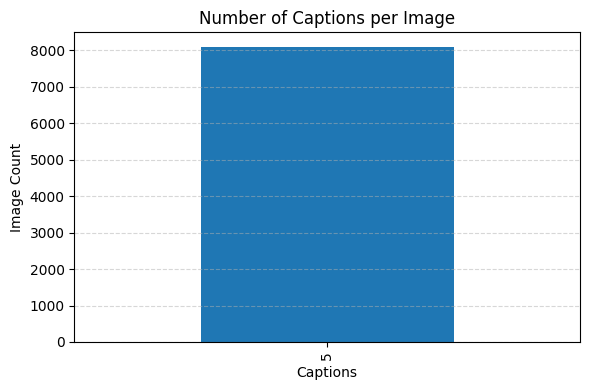

In [8]:
caps_per_img.value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Number of Captions per Image")
plt.xlabel("Captions")
plt.ylabel("Image Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 4.2 Distribusi Panjang Caption

Histogram distribusi jumlah kata (kiri) dan jumlah karakter (kanan) memberikan gambaran tentang sebaran panjang *caption*. Garis vertikal putus-putus (merah) menandai nilai median.

**Analisis:** Sebagian besar *caption* memiliki panjang antara 5–15 kata dengan median sekitar 11 kata. Hanya sedikit *caption* yang memiliki panjang lebih dari 25 kata. Berdasarkan distribusi ini, `MAX_CAPTION_LEN` ditetapkan sebesar 34 untuk memastikan bahwa lebih dari 99% *caption* tercakup tanpa pemotongan yang signifikan.

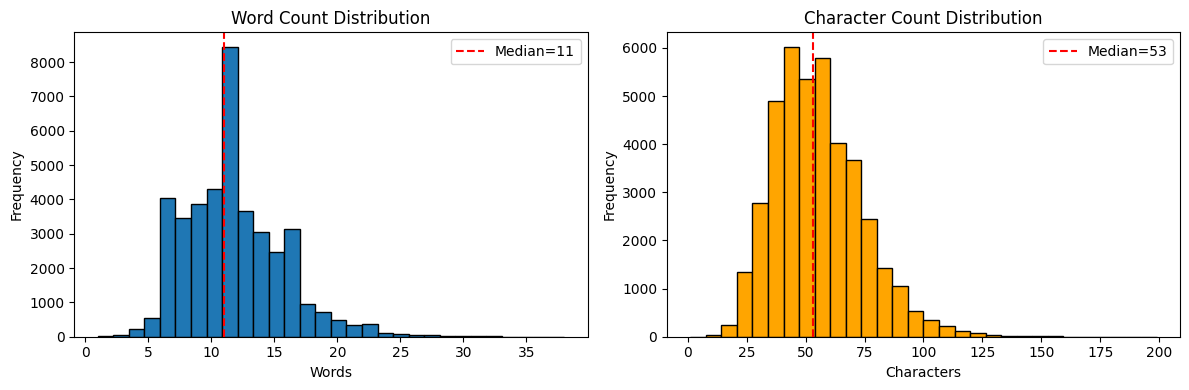

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_count"], bins=30, edgecolor="black")
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["word_count"].median(), color="red",
                linestyle="--", label=f"Median={df['word_count'].median():.0f}")
axes[0].legend()

axes[1].hist(df["char_count"], bins=30, edgecolor="black", color="orange")
axes[1].set_title("Character Count Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df["char_count"].median(), color="red",
                linestyle="--", label=f"Median={df['char_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3 20 Kata Paling Sering Muncul

Grafik batang horizontal ini menampilkan 20 kata dengan frekuensi tertinggi dalam seluruh korpus *caption*.

**Analisis:** Kata-kata seperti "a", "the", "in", "and", dan "on" mendominasi frekuensi, yang merupakan pola umum dalam teks bahasa Inggris. Kata benda seperti "dog", "man", "girl", "boy", dan "woman" juga muncul dengan frekuensi tinggi, mengonfirmasi bahwa dataset banyak memuat gambar yang melibatkan manusia dan hewan dalam berbagai aktivitas.

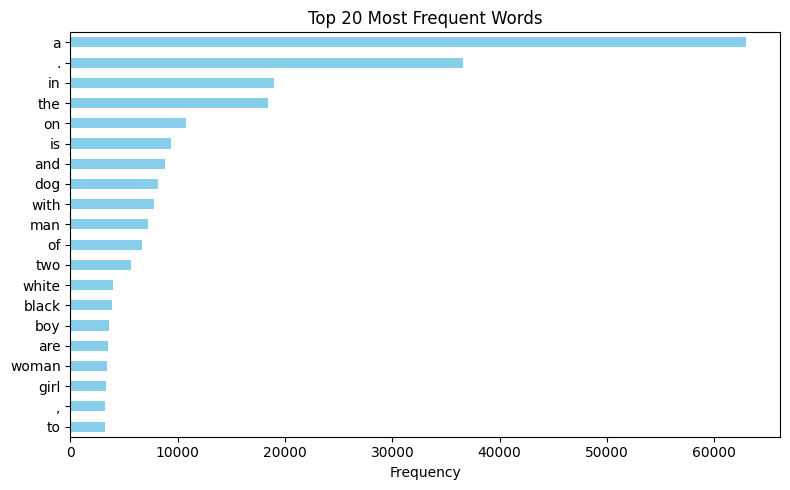

In [10]:
top20 = vocab.head(20)
top20.sort_values().plot(kind="barh", figsize=(8, 5), color="skyblue")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

### 4.4 Contoh Sampel Gambar

Tiga gambar acak ditampilkan beserta kelima *caption*-nya. Visualisasi ini berguna untuk membangun intuisi tentang jenis gambar dan variasi deskripsi yang ada dalam dataset. Perhatikan bahwa setiap *caption* mendeskripsikan gambar yang sama dari sudut pandang yang berbeda.

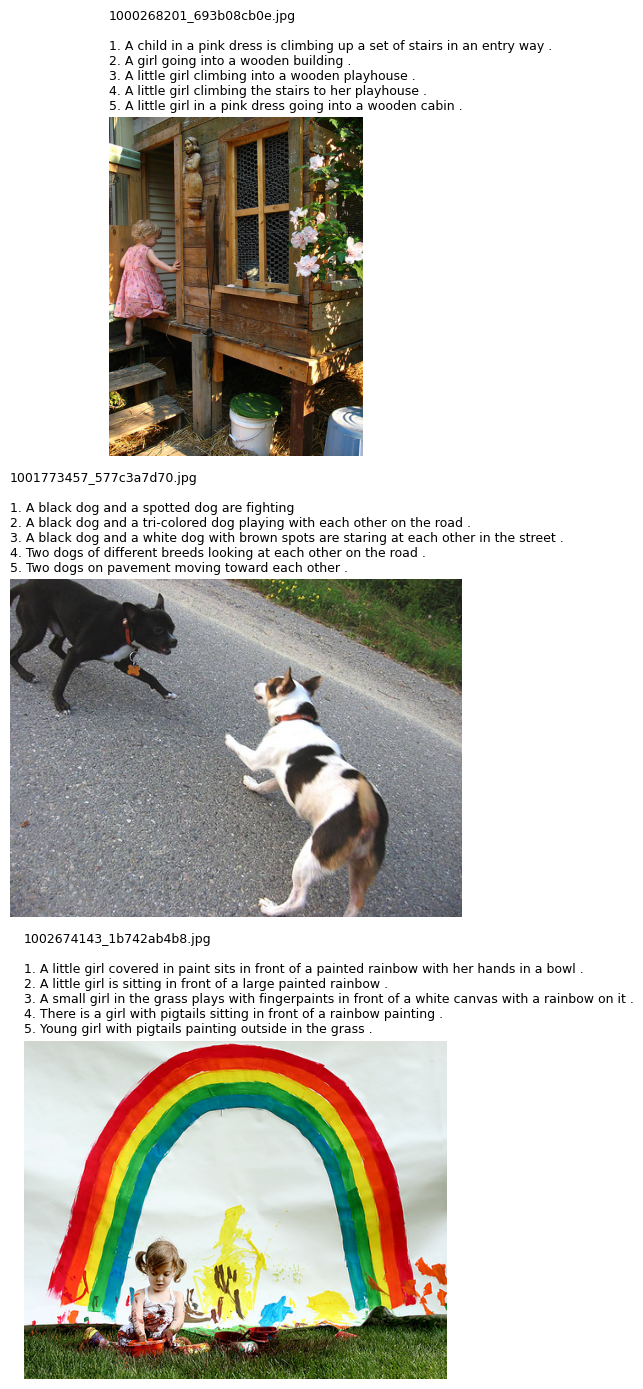

In [11]:
sample_images = df["image"].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(8, 14))

for i, img_name in enumerate(sample_images):
    path = os.path.join(images_dir, img_name)
    img = Image.open(path)

    axes[i].imshow(img)
    axes[i].axis("off")

    caps = df[df["image"] == img_name]["caption"].tolist()
    caption_text = "\n".join(f"{j+1}. {c}" for j, c in enumerate(caps))
    axes[i].set_title(f"{img_name}\n\n{caption_text}",
                      fontsize=9, loc="left")

plt.tight_layout()
plt.show()

## Analisis Hasil dan Observasi

Berdasarkan eksplorasi data di atas, diperoleh temuan-temuan berikut:

1. **Kualitas data baik:** Tidak ditemukan nilai hilang pada dataset. Terdapat 10 baris duplikat dari 40.455 baris, jumlah yang sangat kecil sehingga dapat diabaikan.

2. **Distribusi caption seragam:** Setiap gambar memiliki tepat 5 *caption*, sehingga tidak diperlukan penanganan khusus untuk ketidakseimbangan data.

3. **Panjang caption bervariasi:** Rata-rata *caption* memiliki ~11 kata. Nilai maksimum ~38 kata sebelum pembersihan. Parameter `MAX_CAPTION_LEN=34` ditetapkan sebagai batas atas yang aman.

4. **Ukuran kosakata:** Terdapat 8.918 kata unik dari total 476.665 kata. Angka ini cukup besar, sehingga pembatasan `VOCAB_SIZE=5000` diperlukan untuk efisiensi komputasi sekaligus mencakup sebagian besar kosakata yang relevan.

5. **Domain dataset:** Kata-kata yang dominan ("dog", "man", "running", "playing") mengonfirmasi bahwa dataset Flickr8k didominasi oleh gambar aktivitas luar ruang yang melibatkan manusia dan hewan.

## Ekspor

Pada tahap ini belum diperlukan ekspor data. Seluruh data mentah masih tersimpan di `dataset/captions.txt` dan akan diproses lebih lanjut pada notebook berikutnya.

In [12]:
print("Exploration complete. Proceed to preprocessing.")

Exploration complete. Proceed to preprocessing.


## 5 Wawasan Utama dari Data

Berdasarkan eksplorasi yang telah dilakukan, berikut adalah lima temuan paling penting yang akan memandu keputusan pada tahap selanjutnya:

1. **Distribusi Caption per Gambar Seragam** — Setiap gambar memiliki tepat 5 *caption*, sehingga data siap diproses tanpa penanganan khusus.

2. **Rata-rata Panjang Caption ~11 Kata** — Sebagian besar *caption* berkisar antara 6–15 kata. Nilai `MAX_CAPTION_LEN=34` ditetapkan untuk mencakup lebih dari 99% data.

3. **Kosakata Terbatas dengan Dominasi Kata Umum** — Dari 476.665 total kata, hanya 8.918 kata unik. Dua puluh kata teratas didominasi oleh kata-kata fungsional seperti "the", "a", "in", dan "and".

4. **Objek dan Aktivitas Outdoor Mendominasi** — Kata benda seperti "dog", "man", "girl", dan kata kerja seperti "running", "playing" sering muncul, sesuai dengan karakteristik dataset Flickr8k.

5. **Tidak Ada Anomali Signifikan** — Dataset bersih, tanpa nilai hilang, dengan duplikasi minimal (10 baris dari 40.455), siap untuk tahap pra-pemrosesan.

## Kesimpulan dan Tahap Selanjutnya

Notebook ini berhasil memvalidasi dan mengeksplorasi dataset Flickr8k secara menyeluruh. Parameter-parameter penting yang akan digunakan pada tahap selanjutnya telah diidentifikasi, yaitu `MAX_CAPTION_LEN=34` dan `VOCAB_SIZE=5000`.

**Tahap selanjutnya:** **[02_preprocessing.ipynb](02_preprocessing.ipynb)** — Pembersihan teks *caption* (mengubah ke huruf kecil, menghapus karakter khusus), penambahan token `<start>` dan `<end>`, pembangunan tokenizer, serta pembagian dataset menjadi data latih, validasi, dan uji.